<a href="https://colab.research.google.com/github/Bryan-ing/Master-s-Degree-in-AI/blob/main/Clase5_Bayesiana_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarea Clase 5: Estadística Bayesiana
## Maestría en Inteligencia Artificial

### Instrucciones
Completa los ejercicios marcados con **# TU CÓDIGO AQUÍ**. Cada ejercicio tiene pistas para ayudarte.

---
## 0. Configuración Inicial

In [2]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

%matplotlib inline

print("Librerías importadas")

Librerías importadas


---
## 1. Problema de Diagnóstico Médico

Una prueba médica para una enfermedad tiene las siguientes características:
- **Sensibilidad** (P(Positivo | Enfermo)) = 99%
- **Especificidad** (P(Negativo | Sano)) = 95%
- **Prevalencia** (P(Enfermo)) = 0.1% (1 de cada 1000 personas tiene la enfermedad)

**Pregunta:** Si una persona da positivo en la prueba, ¿cuál es la probabilidad de que realmente esté enferma?

### EJERCICIO 1: Aplicar el Teorema de Bayes (25 puntos)

P(Positivo) = (0.99 × 0.001) + (0.05 × 0.999)
            =    0.00099     +     0.04995
            =    0.05094

In [3]:
#Calcular probabilidades
sensibilidad = 0.99    # P(Positivo | Enfermo)
especificidad = 0.95   # P(Negativo | Sano)
prevalencia = 0.001    # P(Enfermo)

print("=" * 60)
print("PROBLEMA DE DIAGNÓSTICO MÉDICO")
print("=" * 60)

# Prior
p_enfermo = prevalencia #probabilidad de que este enfermo
p_sano = 1 - prevalencia #todo el resto

# Likelihoods (solo las necesarias)
p_positivo_dado_enfermo = sensibilidad
p_positivo_dado_sano = 1 - especificidad

# Denominador
p_positivo = (p_positivo_dado_enfermo * p_enfermo) + \
             (p_positivo_dado_sano * p_sano)  #sumamos ambos denominadores

# Teorema de Bayes
p_enfermo_dado_positivo = (p_positivo_dado_enfermo * p_enfermo) / p_positivo
print(f"P(Enfermo) = {p_enfermo:.3f}")
print(f"P(Sano) = {p_sano:.3f}")
print(f"P(Enfermo | Positivo) = {p_enfermo_dado_positivo:.4f}")
print(f"En porcentaje: {p_enfermo_dado_positivo*100:.2f}%")

PROBLEMA DE DIAGNÓSTICO MÉDICO
P(Enfermo) = 0.001
P(Sano) = 0.999
P(Enfermo | Positivo) = 0.0194
En porcentaje: 1.94%


In [4]:
sensibilidad = 0.99    # P(Positivo | Enfermo)
especificidad = 0.95   # P(Negativo | Sano)
prevalencia = 0.001    # P(Enfermo)

p_enfermo = prevalencia #probabilidad de que este enfermo
p_sano = 1 - prevalencia #todo el resto

# TU CÓDIGO AQUÍ
p_positivo_dado_sano = 1 - especificidad
p_positivo = sensibilidad * prevalencia  +  p_positivo_dado_sano * (1 - prevalencia)
print(f"P(Positivo) = {p_positivo:.4f}")

P(Positivo) = 0.0509


Si quieres saber la probabilidad de un evento, y ese evento puede ocurrir por diferentes caminos, sumas la probabilidad de cada camino.

Tenemos dos posibles diagnosticos:
Sano = .5
Enfermo = .5

In [8]:
#Aplicamos teorema de Bayes
print("=" * 60)
print("PROBLEMA DE Diagnostico Teorema de Bayes")
print("=" * 60)

# Priors
p_enfermo = prevalencia        # 0.001
p_sano = 1 - prevalencia       # 0.999

# Likelihoods
p_positivo_dado_enfermo = sensibilidad
p_positivo_dado_sano = 1 - especificidad

# Denominador
p_positivo = (p_positivo_dado_enfermo * p_enfermo) + \
             (p_positivo_dado_sano * p_sano)

# Teorema de Bayes
p_enfermo_dado_positivo = (p_positivo_dado_enfermo * p_enfermo) / p_positivo #→ Aquí está Bayes — de todos los positivos, ¿cuántos son realmente enfermos?
p_sano_dado_positivo = (p_positivo_dado_sano * p_sano) / p_positivo

print(f"\nPosteriores (después de dar positivo):")
print(f"P(Enfermo | Positivo) = {p_enfermo_dado_positivo:.4f} ({p_enfermo_dado_positivo*100:.2f}%)")
print(f"P(Sano    | Positivo) = {p_sano_dado_positivo:.4f} ({p_sano_dado_positivo*100:.2f}%)")

PROBLEMA DE Diagnostico Teorema de Bayes

Posteriores (después de dar positivo):
P(Enfermo | Positivo) = 0.0194 (1.94%)
P(Sano    | Positivo) = 0.9806 (98.06%)


---
## 2. Problema de las Urnas

Tienes dos urnas:
- **Urna A**: 70% bolas rojas, 30% bolas azules
- **Urna B**: 40% bolas rojas, 60% bolas azules

Eliges una urna al azar y sacas una bola roja. ¿De qué urna es más probable que venga?

### EJERCICIO 2: Problema de las Urnas (25 puntos)

In [9]:
# EJERCICIO 2.1: Define las probabilidades

# TU CÓDIGO AQUÍ
print("=" * 60)
print("PROBLEMA DE LAS URNAS")
print("=" * 60)

# Priors — eliges urna al azar, ambas igual de probable
p_urna_A = 0.5
p_urna_B = 0.5

# Likelihoods — probabilidad de sacar bola roja de cada urna
p_roja_dado_A = 0.70
p_roja_dado_B = 0.40

# Denominador — ley de probabilidad total
p_roja = (p_roja_dado_A * p_urna_A) + \
         (p_roja_dado_B * p_urna_B)

# Teorema de Bayes
p_A_dado_roja = (p_roja_dado_A * p_urna_A) / p_roja
p_B_dado_roja = (p_roja_dado_B * p_urna_B) / p_roja

print(f"\nSi sacaste una bola roja:")
print(f"P(Urna A | Roja) = {p_A_dado_roja:.4f} ({p_A_dado_roja*100:.2f}%)")
print(f"P(Urna B | Roja) = {p_B_dado_roja:.4f} ({p_B_dado_roja*100:.2f}%)")

print(f"\nConclusión: es más probable que venga de la Urna A")

PROBLEMA DE LAS URNAS

Si sacaste una bola roja:
P(Urna A | Roja) = 0.6364 (63.64%)
P(Urna B | Roja) = 0.3636 (36.36%)

Conclusión: es más probable que venga de la Urna A


In [10]:
# EJERCICIO 2.2: Crea la tabla de Bayes

# TU CÓDIGO AQUÍ
# Prior
prior = [p_urna_A, p_urna_B] #hacemos tipo lista para practicar

# Likelihood (probabilidad de sacar roja)
likelihood = [p_roja_dado_A, p_roja_dado_B]

# Unnormalized posterior
unnorm = [prior[0] * likelihood[0], prior[1] * likelihood[1]] #Unnorm es simplemente el numerador de cada opción antes de dividir:

# Normalizar
total = sum(unnorm)
posterior = [unnorm[0] / total, unnorm[1] / total]
#Normalizar es dividir cada uno entre esa suma para que sí sumen 1:

# Tabla
print(f"\nTABLA DE BAYES:")
print(f"{'Urna':8} {'Prior':8} {'Likelihood':12} {'Unnorm':10} {'Posterior':10}")
print(f"{'A':8} {prior[0]:<8.2f} {likelihood[0]:<12.2f} {unnorm[0]:<10.4f} {posterior[0]:.4f}")
print(f"{'B':8} {prior[1]:<8.2f} {likelihood[1]:<12.2f} {unnorm[1]:<10.4f} {posterior[1]:.4f}")
print(f"\nTotal Unnorm = {total:.4f}")


TABLA DE BAYES:
Urna     Prior    Likelihood   Unnorm     Posterior 
A        0.50     0.70         0.3500     0.6364
B        0.50     0.40         0.2000     0.3636

Total Unnorm = 0.5500


Es simplemente el numerador de la fórmula de Bayes separado del denominador:

P(H|E) = P(H) · P(E|H)    ← esto es el Unnorm
         ──────────────
              P(E)          ← esto es normalizar

In [11]:
# EJERCICIO 2.3: Interpreta los resultados

# TU CÓDIGO AQUÍ
# EJERCICIO 2.3: Interpreta los resultados

# Determina cuál es más probable
if posterior[0] > posterior[1]:
    ganador = "Urna A"
    prob_ganador = posterior[0]
else:
    ganador = "Urna B"
    prob_ganador = posterior[1]

print(f"La bola roja es más probable que venga de la: {ganador}")
print(f"Con una probabilidad de: {prob_ganador*100:.2f}%")
print(f"\nInterpretación:")
print(f"Aunque elegiste la urna al azar (50/50),")
print(f"el hecho de haber sacado una bola roja actualiza")
print(f"la probabilidad hacia la Urna A porque tiene")
print(f"más bolas rojas (70%) que la Urna B (40%).")

La bola roja es más probable que venga de: Urna A
Con una probabilidad de: 63.64%

Interpretación:
Aunque elegiste la urna al azar (50/50),
el hecho de haber sacado una bola roja actualiza
la probabilidad hacia la Urna A porque tiene
más bolas rojas (70%) que la Urna B (40%).


---
## 3. Actualización Bayesiana con Múltiples Observaciones

Continuando con el problema de las urnas, ahora sacas 5 bolas con reemplazo:
- 3 rojas
- 2 azules

Actualiza tus creencias después de cada extracción.

### EJERCICIO 3: Actualización Iterativa (25 puntos)

In [12]:
print("═" * 60)
print("ACTUALIZACIÓN ITERATIVA")
print("═" * 60)

# Secuencia de extracciones
extracciones = ['roja', 'roja', 'roja', 'azul', 'azul']

# Probabilidades de cada color por urna
likelihoods = {
    'Urna A': {'roja': 0.7, 'azul': 0.3},
    'Urna B': {'roja': 0.4, 'azul': 0.6}
}

# Inicializar priors
p_a = 0.5
p_b = 0.5

print(f"\n Secuencia de extracciones: {extracciones}")
print("\n" + "-" * 60)

# Historial para visualización
history = [(p_a, p_b)]

for i, color in enumerate(extracciones, 1): #recorrer cad auna de las bolas que sacamos
    print(f"\n Paso {i}: Sacamos {color.upper()}")
    print(f"   Antes: P(Urna A) = {p_a:.4f}, P(Urna B) = {p_b:.4f}")
    # Likelihoods de la bola que salió
    l_a = likelihoods['Urna A'][color]
    l_b = likelihoods['Urna B'][color]

    # Unnormalized
    unnorm_a = p_a * l_a #Prior × likelihood de cada urna — el numerador de Bayes antes de dividir.
    unnorm_b = p_b * l_b

    # Normalizar
    total = unnorm_a + unnorm_b
    p_a = unnorm_a / total
    p_b = unnorm_b / total
    #Divides entre la suma para que los dos sumen 1:

    # Guardar en historial
    history.append((p_a, p_b))

    print(f"  Después: P(Urna A) = {p_a:.4f}, P(Urna B) = {p_b:.4f}")

════════════════════════════════════════════════════════════
ACTUALIZACIÓN ITERATIVA
════════════════════════════════════════════════════════════

 Secuencia de extracciones: ['roja', 'roja', 'roja', 'azul', 'azul']

------------------------------------------------------------

 Paso 1: Sacamos ROJA
   Antes: P(Urna A) = 0.5000, P(Urna B) = 0.5000
  Después: P(Urna A) = 0.6364, P(Urna B) = 0.3636

 Paso 2: Sacamos ROJA
   Antes: P(Urna A) = 0.6364, P(Urna B) = 0.3636
  Después: P(Urna A) = 0.7538, P(Urna B) = 0.2462

 Paso 3: Sacamos ROJA
   Antes: P(Urna A) = 0.7538, P(Urna B) = 0.2462
  Después: P(Urna A) = 0.8428, P(Urna B) = 0.1572

 Paso 4: Sacamos AZUL
   Antes: P(Urna A) = 0.8428, P(Urna B) = 0.1572
  Después: P(Urna A) = 0.7282, P(Urna B) = 0.2718

 Paso 5: Sacamos AZUL
   Antes: P(Urna A) = 0.7282, P(Urna B) = 0.2718
  Después: P(Urna A) = 0.5726, P(Urna B) = 0.4274


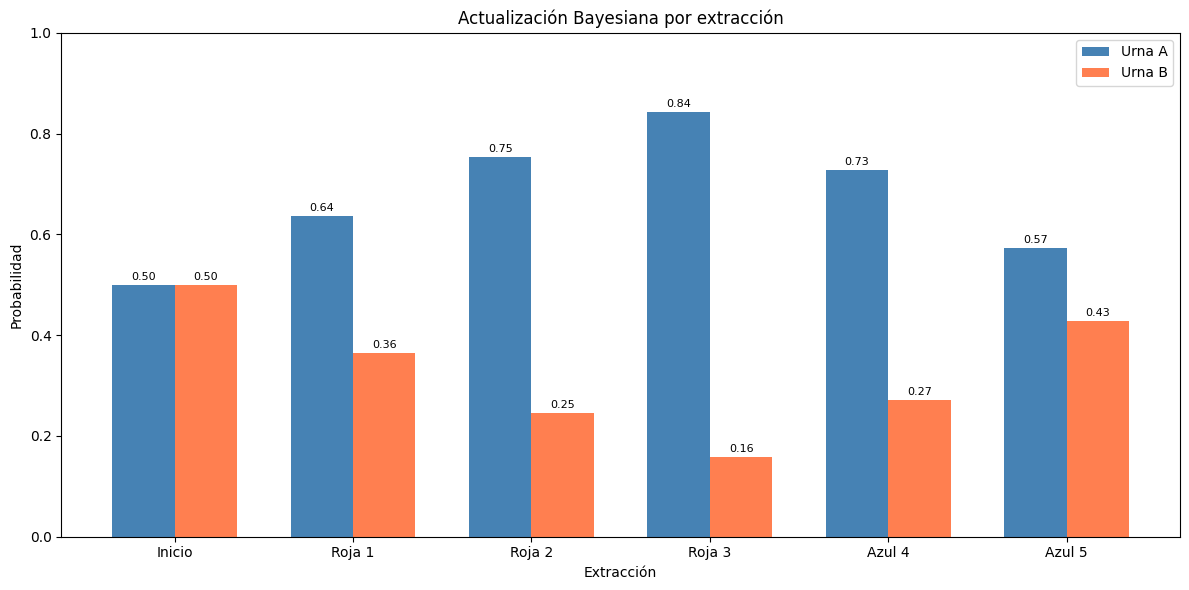

In [16]:
# EJERCICIO 3.2: Visualiza la actualización

fig, ax = plt.subplots(figsize=(12, 6))

steps = ['Inicio'] + [f'{e.capitalize()} {i+1}' for i, e in enumerate(extracciones)]
urna_a_probs = [h[0] for h in history]
urna_b_probs = [h[1] for h in history]

x = np.arange(len(steps))
width = 0.35
# TU CÓDIGO AQUÍ
# Dibuja barras lado a lado — negativo va izquierda, positivo va derecha
ax.bar(x - width/2, urna_a_probs, width, label='Urna A', color='steelblue')
ax.bar(x + width/2, urna_b_probs, width, label='Urna B', color='coral')

ax.set_xlabel('Extracción')
ax.set_ylabel('Probabilidad')
ax.set_title('Actualización Bayesiana por extracción')
# Coloca las etiquetas del eje X — Inicio, Roja1, Roja2...
ax.set_xticks(x)
ax.set_xticklabels(steps)
ax.legend()
ax.set_ylim(0, 1)  # probabilidad siempre entre 0 y 1

# Añadir valores sobre las barras
# zip recorre ambas listas al mismo tiempo par por par
for i, (va, vb) in enumerate(zip(urna_a_probs, urna_b_probs)):
    # +0.01 para que el texto no se empalme con la barra
    ax.text(i - width/2, va + 0.01, f'{va:.2f}', ha='center', fontsize=8)
    ax.text(i + width/2, vb + 0.01, f'{vb:.2f}', ha='center', fontsize=8)

plt.tight_layout()  # ajusta espacios para que no se corte nada
plt.show()

---
## 4. Estimación de una Proporción

Quieres estimar la proporción de personas que prefieren el té sobre el café.

- **Prior**: Distribución Beta(2, 2) (creencia inicial: proporción alrededor de 0.5)
- **Datos**: Encuestas a 50 personas, 30 prefieren té

Actualiza tu creencia con los datos.

### EJERCICIO 4: Estimación Bayesiana (25 puntos)

In [17]:
print("═" * 60)
print("ESTIMACIÓN DE PROPORCIÓN: Té vs Café")
print("═" * 60)

# Datos
alpha_prior = 2
beta_prior = 2
n_encuestados = 50
n_te = 30

print(f"\n Datos:")
print(f"  Prior: Beta({alpha_prior}, {beta_prior})")
print(f"  Encuestados: {n_encuestados}")
print(f"  Prefieren té: {n_te}")
print(f"  Proporción muestral: {n_te/n_encuestados:.2f}")

# EJERCICIO 4.1: Calcula la posterior

# TU CÓDIGO AQUÍ
# Actualizar parámetros — suma directa
alpha_posterior = alpha_prior + n_te
beta_posterior = beta_prior + (n_encuestados - n_te)

# Media y moda de la posterior
# Media = alpha / (alpha + beta)
media = alpha_posterior / (alpha_posterior + beta_posterior)

# Moda = (alpha - 1) / (alpha + beta - 2)
moda = (alpha_posterior - 1) / (alpha_posterior + beta_posterior - 2)

print(f"\nPosterior: Beta({alpha_posterior}, {beta_posterior})")
print(f"Media     = {media:.4f} ({media*100:.2f}%)")
print(f"Moda      = {moda:.4f} ({moda*100:.2f}%)")

════════════════════════════════════════════════════════════
ESTIMACIÓN DE PROPORCIÓN: Té vs Café
════════════════════════════════════════════════════════════

 Datos:
  Prior: Beta(2, 2)
  Encuestados: 50
  Prefieren té: 30
  Proporción muestral: 0.60

Posterior: Beta(32, 22)
Media     = 0.5926 (59.26%)
Moda      = 0.5962 (59.62%)


In [18]:
# EJERCICIO 4.2: Calcula el intervalo de credibilidad 95%
from scipy import stats

# Construye la distribución Beta con los parámetros posteriores
# es como "materializar" la curva de creencias actualizada
posterior = stats.beta(alpha_posterior, beta_posterior)

# ppf = percentile point function — inverso de la probabilidad
# le preguntas: ¿qué valor deja X% de probabilidad por debajo?
limite_inferior = posterior.ppf(0.025)  # corta el 2.5% inferior
limite_superior = posterior.ppf(0.975)  # corta el 2.5% superior
# entre ambos queda el 95% central

print(f"Intervalo de credibilidad 95%:")
print(f"  Límite inferior = {limite_inferior:.4f} ({limite_inferior*100:.2f}%)")
print(f"  Límite superior = {limite_superior:.4f} ({limite_superior*100:.2f}%)")
print(f"\n  Hay 95% de probabilidad de que la proporción")
print(f"  real esté entre {limite_inferior*100:.1f}% y {limite_superior*100:.1f}%")

Intervalo de credibilidad 95%:
  Límite inferior = 0.4600 (46.00%)
  Límite superior = 0.7186 (71.86%)

  Hay 95% de probabilidad de que la proporción
  real esté entre 46.0% y 71.9%


Posterior: Beta(32, 22)
Media     = 0.5926 (59.26%)
Moda      = 0.5962 (59.62%)

Intervalo de credibilidad 95%:
  Límite inferior = 0.4600 (46.00%)
  Límite superior = 0.7186 (71.86%)


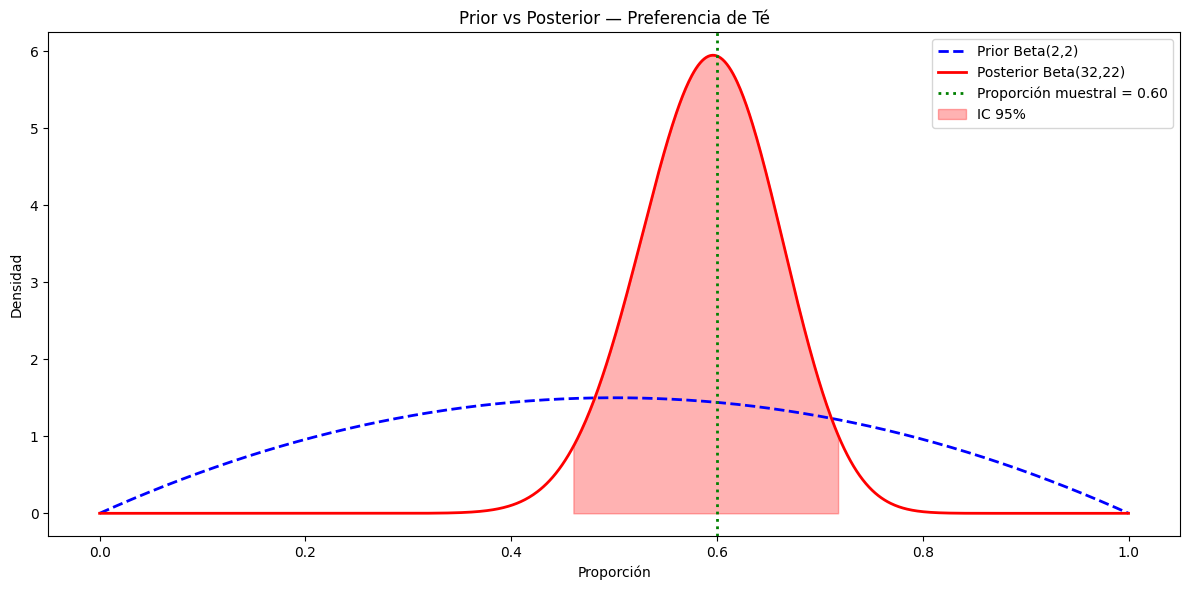

In [23]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

# Definir todo desde cero sin depender de celdas anteriores
alpha_prior = 2
beta_prior = 2
n_encuestados = 50
n_te = 30

# EJERCICIO 4.1 — Calcular posterior
# Beta se actualiza sumando directamente los nuevos datos
alpha_posterior = alpha_prior + n_te
beta_posterior = beta_prior + (n_encuestados - n_te)

# Media = alpha / (alpha + beta) — centro de masa
media = alpha_posterior / (alpha_posterior + beta_posterior)
# Moda = (alpha-1) / (alpha+beta-2) — valor más probable
moda = (alpha_posterior - 1) / (alpha_posterior + beta_posterior - 2)

print(f"Posterior: Beta({alpha_posterior}, {beta_posterior})")
print(f"Media     = {media:.4f} ({media*100:.2f}%)")
print(f"Moda      = {moda:.4f} ({moda*100:.2f}%)")

# EJERCICIO 4.2 — Intervalo de credibilidad 95%
# Construye las distribuciones como objetos para hacer cálculos
prior_dist = stats.beta(alpha_prior, beta_prior)
posterior_dist = stats.beta(alpha_posterior, beta_posterior)

# ppf corta 2.5% de cada lado dejando 95% en el centro
limite_inferior = posterior_dist.ppf(0.025)
limite_superior = posterior_dist.ppf(0.975)
proporcion_muestral = n_te / n_encuestados

print(f"\nIntervalo de credibilidad 95%:")
print(f"  Límite inferior = {limite_inferior:.4f} ({limite_inferior*100:.2f}%)")
print(f"  Límite superior = {limite_superior:.4f} ({limite_superior*100:.2f}%)")

# EJERCICIO 4.3 — Visualizar prior y posterior
fig, ax = plt.subplots(figsize=(12, 6))

# 1000 puntos entre 0 y 1 — eje X representa proporciones posibles
x = np.linspace(0, 1, 1000)

# Prior — curva ANTES de ver los datos
ax.plot(x, prior_dist.pdf(x), 'b--',
        label=f'Prior Beta({alpha_prior},{beta_prior})', linewidth=2)

# Posterior — más angosta = más certeza después de ver los datos
ax.plot(x, posterior_dist.pdf(x), 'r-',
        label=f'Posterior Beta({alpha_posterior},{beta_posterior})', linewidth=2)

# Línea vertical donde cayó el dato observado
ax.axvline(proporcion_muestral, color='green', linestyle=':', linewidth=2,
           label=f'Proporción muestral = {proporcion_muestral:.2f}')

# Sombrear IC 95% — where define la condición de coloreado
ax.fill_between(x, posterior_dist.pdf(x),
                where=(x >= limite_inferior) & (x <= limite_superior),
                alpha=0.3, color='red', label='IC 95%')

ax.set_xlabel('Proporción')
ax.set_ylabel('Densidad')
ax.set_title('Prior vs Posterior — Preferencia de Té')
ax.legend()
plt.tight_layout()
plt.show()

---
## Checklist de Entrega

- [ ] Todos los ejercicios de código están completos
- [ ] Las visualizaciones se muestran correctamente
- [ ] Los cálculos del Teorema de Bayes son correctos
- [ ] Las interpretaciones son claras
- [ ] El notebook se ejecuta sin errores

**Formato de entrega:** Sube el archivo `.ipynb` a la plataforma del curso.